In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [222]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 48)


In [223]:
# Remover colunas problemáticas
df = df.drop(columns=[
    'id','pesid','id_veiculo',
    'mortos','feridos_leves','feridos_graves',
    'total_vitimas','gravidade_numerica','estado_fisico','ilesos','Modelo_Grupo',
    'uop',
    'delegacia',
    'regional'
])
print("Shape drop:", df.shape)

Shape drop: (1678326, 34)


In [224]:
df = df.dropna(subset=['classificacao_acidente'])
df = df.dropna(subset=['br', 'km'])


In [225]:
print("Shape drop:", df.shape)

Shape drop: (1673475, 34)


In [226]:
df.isnull().sum().sort_values(ascending=False).head(10)

idade              130622
data_inversa            0
dia_semana              0
horario                 0
br                      0
uf                      0
municipio               0
causa_principal         0
causa_acidente          0
km                      0
dtype: int64

In [227]:
# Criar target
mapping_binario = {
    'Sem Vítimas': 0,
    'Com Vítimas Feridas': 1,
    'Com Vítimas Fatais': 1
}

df['target'] = df['classificacao_acidente'].map(mapping_binario)

In [228]:
features = [
    # Temporais
    'hora',
    'mes',
    'dia_semana',
    'fase_dia',
    
    # Ambientais
    'condicao_metereologica',
    
    # Infraestrutura
    'tipo_pista',
    'tracado_via',
    'uso_solo',
    'uf',
    'km',
    
    # Tipo do sinistro
    'tipo_acidente',
    
    # Veículo
    'ano_fabricacao_veiculo',

    'latitude',
    'longitude'
]

In [229]:
df_model = df[features + ['target']].copy()

In [230]:
df_model = df_model.dropna()
print("Shape final modelagem:", df_model.shape)

Shape final modelagem: (1673475, 15)


In [231]:
df_model['hora_sin'] = np.sin(2 * np.pi * df_model['hora'] / 24)
df_model['hora_cos'] = np.cos(2 * np.pi * df_model['hora'] / 24)

df_model = df_model.drop(columns=['hora'])

In [232]:
df_model['idade_veiculo'] = 2025 - df_model['ano_fabricacao_veiculo']
df_model = df_model.drop(columns=['ano_fabricacao_veiculo'])

In [233]:
df_model['fim_semana'] = df_model['dia_semana'].isin(
    ['sábado','domingo']
).astype(int)

In [234]:
# Corrigir latitude
df_model['latitude'] = (
    df_model['latitude']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_model['latitude'] = pd.to_numeric(df_model['latitude'], errors='coerce')

# Corrigir longitude
df_model['longitude'] = (
    df_model['longitude']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_model['longitude'] = pd.to_numeric(df_model['longitude'], errors='coerce')

In [235]:
df_model['latitude'] = df_model['latitude'].astype('float32')
df_model['longitude'] = df_model['longitude'].astype('float32')

In [236]:
coords = df_model[['latitude','longitude']].copy()

sample_coords = coords.sample(200000, random_state=42)

kmeans = KMeans(n_clusters=30, random_state=42, n_init=10)
kmeans.fit(sample_coords)

df_model['cluster_regiao'] = kmeans.predict(coords)
df_model['cluster_regiao'] = df_model['cluster_regiao'].astype('category')

In [237]:
df_model['km'] = (
    df_model['km']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_model['km'] = pd.to_numeric(df_model['km'], errors='coerce')

In [238]:
numeric_cols = [
    'mes',
    'km',
    'latitude',
    'longitude',
    'hora_sin',
    'hora_cos',
    'idade_veiculo'
]

for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    df_model[col] = df_model[col].astype('float32')

In [239]:
categorical_cols = [
    'dia_semana',
    'fase_dia',
    'uf',
    'condicao_metereologica',
    'tipo_pista',
    'tracado_via',
    'uso_solo',
    'tipo_acidente',
    'cluster_regiao'
]

for col in categorical_cols:
    df_model[col] = df_model[col].astype('category')

In [240]:
df_model = df_model.dropna()

In [241]:
X = df_model.drop(columns=['target'])
y = df_model['target']

In [242]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [243]:
model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

[LightGBM] [Info] Number of positive: 1181458, number of negative: 157322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1240
[LightGBM] [Info] Number of data points in the train set: 1338780, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.882489 -> initscore=2.016210
[LightGBM] [Info] Start training from score 2.016210


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [244]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.10      0.18     39331
           1       0.89      1.00      0.94    295364

    accuracy                           0.89    334695
   macro avg       0.87      0.55      0.56    334695
weighted avg       0.89      0.89      0.85    334695

[[  3963  35368]
 [   762 294602]]


In [245]:
from collections import Counter

counter = Counter(y_train)
print(counter)

Counter({1: 1181458, 0: 157322})


In [246]:
scale_pos_weight = counter[1] / counter[0]

print(scale_pos_weight)

7.509807909891815


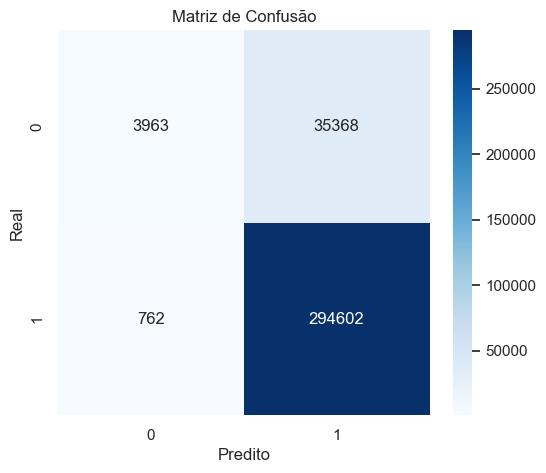

In [247]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

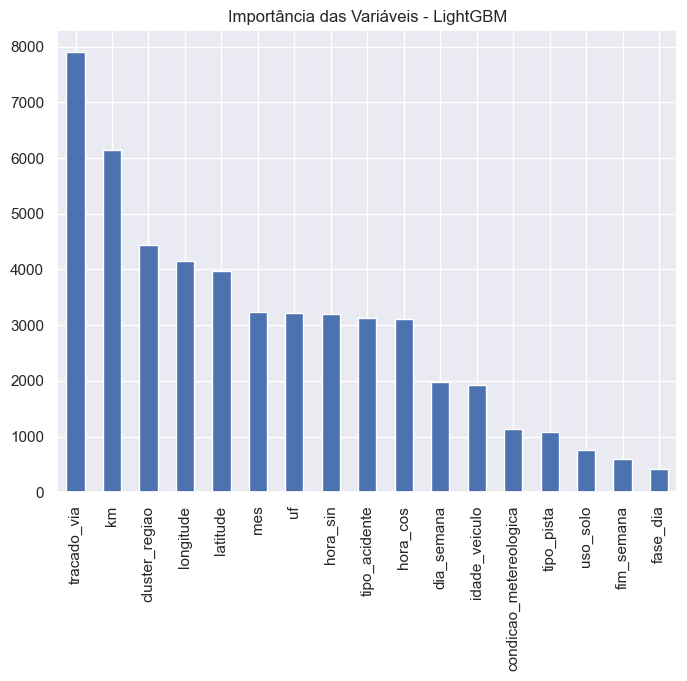

In [248]:
importances = pd.Series(
    model.feature_importances_,
    index=model.feature_name_
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='bar')
plt.title("Importância das Variáveis - LightGBM")
plt.show()

In [249]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)

,feature,importance
5,tracado_via,7896
8,km,6147
16,cluster_regiao,4438
11,longitude,4145
10,latitude,3969
0,mes,3229
7,uf,3226
12,hora_sin,3199
9,tipo_acidente,3123
13,hora_cos,3114
